Este notebook tiene como objetivo analizar mediante Interpolacion por Distancia Inversa Ponderada (IDW por sus siglas en inglés) si los datos observados en 8 estaciones meteorológicas vecinas, son homogeneos a una estación central ubicada en el municipio de Juchitepec en el Estado de México.

Para este análisis se cuentan con los 9 conjuntos de datos de cada estación y sus coordendas, cada uno contiene distintos rangos de fechas para las variables de precepitación (PRECIP), evaporación (EVAP), temperatura máxima (TMAX) y temperatura mínima (TMIN), estas se miden en milimetros y grados centigrados.

# 1. Librerías y factores de penalización por altitud


En esta primer celda se consideran dos factores que penalizan la altitud de las estaciones meteorológicas, dependiendo la variable que se desee analizar, para la temperatura se multiplica cada metro de diferencia que se tenga con la estación central en Juchitepec por -0.0065, bajo el supuesto de que cada 1000 metros sobre el nivel del mar la temperatura se ve disminuida en 6.5°C.

Para la precipitación se propone un valor de penalización de 50 unidades por cada metro de diferencia, esto se traduce en que si una estación meteorológica esta 100 metros arriba o abajo de la estación central se multiplique la distancia 2d entre las estaciones por 50 unidades, resultando en que se alejen 5km de manera teorica, disminuyendo así el peso que esta tiene sobre la ponderación final; el fundamento de este valor es que las nubes al chocar con una montaña o un terreno más elevado, tienden a ascender, enfriarse y descargar lluvia de un solo lado, dejando el otro seco. El valor de 50 se propone inicialmente como una constante empirica en climatología, pero más adelante este valor se justifica mediante una prueba con distintos valores de penalización para determinar, mediante RMSE, cual es el óptimo.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import folium

plt.style.use('ggplot')

# Constantes
RADIO_TIERRA_KM = 6371.0
GRADIENTE_TERMICO = -0.0065  # En grados Celsius por metro
FACTOR_PENALIZACION_ALTITUD = 50

print(f"Parametros configurados:")
print(f" - Gradiente termico vertical: {GRADIENTE_TERMICO} C/m")
print(f" - Factor de penalizacion (Precip/Evap): {FACTOR_PENALIZACION_ALTITUD}")

Parametros configurados:
 - Gradiente termico vertical: -0.0065 C/m
 - Factor de penalizacion (Precip/Evap): 50


# 2. Conjuntos de datos y coordenadas

Aquí se cargan los archivos CSV construidos a partir de la CONAGUA, que tiene registros dirios y mensuales de estaciones meteorológicas distribuidas en todo el país, así como sus coordenadas. Se representa con un mapa para observar las ubicaciones de la estación central (Juchitepec) y las vecinas que se consideran para el análisis de sus datos mediante IDW.

https://smn.conagua.gob.mx/es/climatologia/informacion-climatologica/informacion-estadistica-climatologica

In [20]:
# (Latitud, Longitud, Altitud)
estaciones_info = {
    'CENTRAL': (19.08694444, -98.88472222, 2543), # Juchitepec
    'SANTA_ANA_TLACOTENCO': (19.17888889, -99.00277778, 2595),
    'SAN_LUIS_AMECA': (19.19027778, -98.87083333, 2285),
    'TLAMANALCO': (19.20388889, -98.80333333, 2410),
    'AMECAMECA_DE_JUAREZ': (19.14055556, -98.77222222, 2470),
    'SAN_PEDRO_NEXAPA': (19.08361111, -98.73833333, 2620),
    'ATLAUTLA': (19.02694444, -98.77972222, 2350),
    'TOTOLAPAN': (18.98694444, -98.91972222, 1908),
    'EL_VIGIA': (19.01, -98.96, 2160)
}

archivos = {
    'CENTRAL': 'Datos_diarios_Juchitepec_01-01-1969_a_31-10-2025.csv',
    'SANTA_ANA_TLACOTENCO': 'Datos_diarios_Santa_Ana_Tlacotenco_01-01-1969_a_31-10-2025.csv',
    'SAN_LUIS_AMECA': 'Datos_diarios_San_Luis_Ameca_01-01-1961_a_31-05-2025.csv',
    'TLAMANALCO': 'Datos_diarios_Tlamanalco_01-01-1981_a_31-10-2025.csv',
    'AMECAMECA_DE_JUAREZ': 'Datos_diarios_Amecameca_de_Juarez_14-03-1969_a_30-09-2025.csv',
    'SAN_PEDRO_NEXAPA': 'Datos_diarios_San_Pedro_Nexapa_01-02-1961_a_31-10-2025.csv',
    'ATLAUTLA': 'Datos_diarios_Atlautla_01-07-1978_a_30-04-2025.csv',
    'TOTOLAPAN': 'Datos_diarios_Totolapan_01-01-1976_a_31-12-2025.csv',
    'EL_VIGIA': 'Datos_diarios_El_Vigia_01-01-1981_a_31-10-2025.csv'
}

# Calcular el centroide para centrar el mapa
lats = [coords[0] for coords in estaciones_info.values()]
lons = [coords[1] for coords in estaciones_info.values()]
centro_mapa = [sum(lats) / len(lats), sum(lons) / len(lons)]

# Mapa base
mapa_estaciones = folium.Map(location=centro_mapa, zoom_start=11, tiles='OpenStreetMap')

# Marcadores
for nombre, coords in estaciones_info.items():
    lat, lon, alt = coords
    nombre_display = nombre.replace('_', ' ')

    if nombre == 'CENTRAL':
        folium.Marker(
            location=[lat, lon],
            popup=f"<b>JUCHITEPEC (CENTRAL)</b><br>Altitud: {alt} m",
            icon=folium.Icon(color='red', icon='star')
        ).add_to(mapa_estaciones)
    else:
        folium.Marker(
            location=[lat, lon],
            popup=f"<b>{nombre_display}</b><br>Altitud: {alt} m",
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(mapa_estaciones)

print("Visualizando mapa de estaciones...")

display(mapa_estaciones)

Visualizando mapa de estaciones...


# 3. Carga y limpieza de los datos

Aquí se cargan los datos en un DataFrame y se filtran por las fechas de interes (01/01/2015 a 31/12/2024) de acuerdo con el protocolo, es decir, 10 años en retrospectiva al año que se pretende predecir. Se hace una linea temporal de tempratura máxima observada en el rango de interés.

Iniciando lectura de archivos CSV...
 -> CENTRAL: 3564 registros cargados (2015-2024).
 -> SANTA_ANA_TLACOTENCO: 3531 registros cargados (2015-2024).
 -> SAN_LUIS_AMECA: 3622 registros cargados (2015-2024).
 -> TLAMANALCO: 3622 registros cargados (2015-2024).
 -> AMECAMECA_DE_JUAREZ: 3590 registros cargados (2015-2024).
 -> SAN_PEDRO_NEXAPA: 3194 registros cargados (2015-2024).
 -> ATLAUTLA: 3500 registros cargados (2015-2024).
 -> TOTOLAPAN: 3287 registros cargados (2015-2024).
 -> EL_VIGIA: 3653 registros cargados (2015-2024).


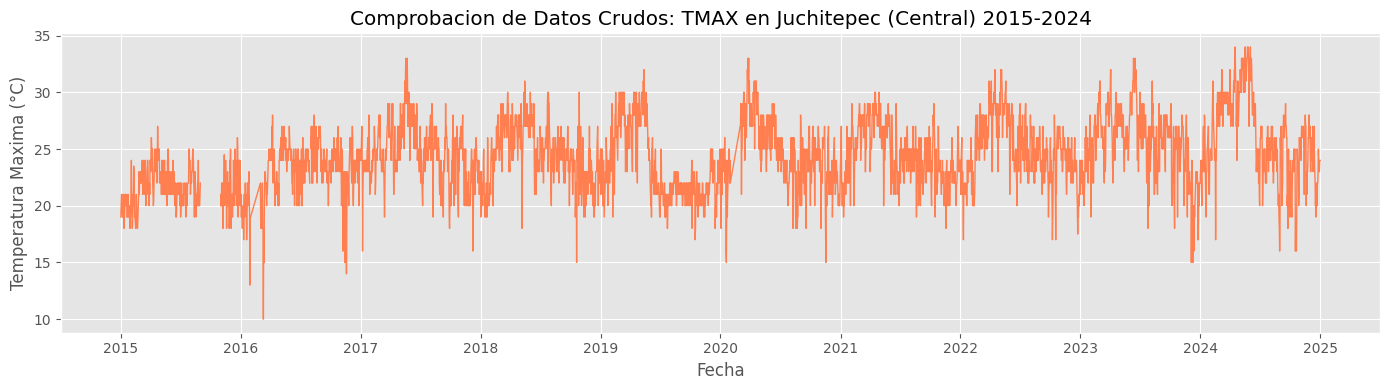

In [21]:
def cargar_datos(ruta):
    if not os.path.exists(ruta):
        print(f"Archivo no encontrado: {ruta}")
        return pd.DataFrame()

    df = pd.read_csv(ruta)

    # --- CORRECCIÓN DE FECHAS ---
    # dayfirst=True le indica a Pandas que lea Día/Mes/Año.
    # format='mixed' evita errores si hay variaciones sutiles en la columna.
    df['FECHA'] = pd.to_datetime(df['FECHA'], dayfirst=True, format='mixed')

    # Filtrar estrictamente de 2015 a 2024
    mask = (df['FECHA'] >= '2015-01-01') & (df['FECHA'] <= '2024-12-31')
    df = df.loc[mask].copy()
    df.set_index('FECHA', inplace=True)

    cols = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

datos_dfs = {}
print("Iniciando lectura de archivos CSV...")
for nombre, ruta in archivos.items():
    df_cargado = cargar_datos(ruta)
    if not df_cargado.empty:
        datos_dfs[nombre] = df_cargado
        print(f" -> {nombre}: {len(df_cargado)} registros cargados (2015-2024).")


# Grafica para verificar visualmente los datos cargados en la Central
if 'CENTRAL' in datos_dfs and not datos_dfs['CENTRAL'].empty:
    plt.figure(figsize=(14, 4))
    plt.plot(datos_dfs['CENTRAL'].index, datos_dfs['CENTRAL']['TMAX'], color='coral', linewidth=1)
    plt.title('Comprobacion de Datos Crudos: TMAX en Juchitepec (Central) 2015-2024')
    plt.ylabel('Temperatura Maxima (°C)')
    plt.xlabel('Fecha')
    plt.tight_layout()
    plt.show()
else:
    print("Asegurate de que el archivo CSV de Juchitepec este en la misma carpeta que esta libreta para generar la grafica.")

En esta celda comprobamos con cuantos datos porcentualemnte disponemos de los 10 años, en cada variable de cada estación, y al observar que no tenemos ningún registro de la variable EVAP (evaporación) en la estación central, decidimos descartarla para su análisis.

In [22]:
print("==================================================")
print("ANALISIS DE CALIDAD DE DATOS (2015 - 2024)")
print("==================================================")

# Rango de fechas esperado
fecha_inicio = '2015-01-01'
fecha_fin = '2024-12-31'
# Calculamos los días totales reales en esa década (incluye bisiestos)
dias_esperados = (pd.to_datetime(fecha_fin) - pd.to_datetime(fecha_inicio)).days + 1

for nombre, df in datos_dfs.items():
    if df.empty:
        continue

    registros_reales = len(df)
    dias_ausentes = dias_esperados - registros_reales
    porcentaje_ausentes = (dias_ausentes / dias_esperados) * 100

    print(f"\nEstacion: {nombre}")
    print(f" -> Dias con registro: {registros_reales} de {dias_esperados}")
    print(f" -> Dias completamente ausentes en el CSV: {dias_ausentes} ({porcentaje_ausentes:.2f}%)")

    # Calcular el porcentaje de valores nulos (NaN) para cada columna
    print(" -> Porcentaje de datos nulos por variable (celdas vacias):")
    nulos_pct = df[['PRECIP', 'EVAP', 'TMAX', 'TMIN']].isna().mean() * 100

    for col, pct in nulos_pct.items():
        if pct == 0:
            print(f"    * {col}: 0.00% (Completo)")
        elif pct > 20:
            # Resaltar si falta más del 20% de la información (suele ser crítico para IDW)
            print(f"    * {col}: {pct:.2f}% nulo **")
        else:
            print(f"    * {col}: {pct:.2f}% nulo")

print("\n==================================================")

ANALISIS DE CALIDAD DE DATOS (2015 - 2024)

Estacion: CENTRAL
 -> Dias con registro: 3564 de 3653
 -> Dias completamente ausentes en el CSV: 89 (2.44%)
 -> Porcentaje de datos nulos por variable (celdas vacias):
    * PRECIP: 0.84% nulo
    * EVAP: 100.00% nulo **
    * TMAX: 0.95% nulo
    * TMIN: 0.95% nulo

Estacion: SANTA_ANA_TLACOTENCO
 -> Dias con registro: 3531 de 3653
 -> Dias completamente ausentes en el CSV: 122 (3.34%)
 -> Porcentaje de datos nulos por variable (celdas vacias):
    * PRECIP: 0.11% nulo
    * EVAP: 7.65% nulo
    * TMAX: 0.14% nulo
    * TMIN: 0.14% nulo

Estacion: SAN_LUIS_AMECA
 -> Dias con registro: 3622 de 3653
 -> Dias completamente ausentes en el CSV: 31 (0.85%)
 -> Porcentaje de datos nulos por variable (celdas vacias):
    * PRECIP: 0.00% (Completo)
    * EVAP: 0.91% nulo
    * TMAX: 0.00% (Completo)
    * TMIN: 0.00% (Completo)

Estacion: TLAMANALCO
 -> Dias con registro: 3622 de 3653
 -> Dias completamente ausentes en el CSV: 31 (0.85%)
 -> Porcenta

# 4. Calculo de distancias

En esta celda se obtienen las distancias 2d entre la estación central con las estaciones vecinas mediante el método de Haversine, para distancias esfericas; este paso es para la más adelante realizar la ponderación de las estaciones vecinas sobre la central.

La distancia 2d se calcula considerando unicamente considerando la latitud y longitud de las estaciones, más adelante se considera la altitud como una forma de penalizar las ponderaciones en el IDW.

In [23]:
def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia horizontal real entre dos coordenadas geograficas
    usando la formula de Haversine (toma en cuenta la curvatura de la Tierra).
    Devuelve la distancia en METROS.
    """
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    a = (math.sin(dLat / 2) * math.sin(dLat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dLon / 2) * math.sin(dLon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return (RADIO_TIERRA_KM * c) * 1000  # Distancia en metros

print("==================================================")
print("           DISTANCIAS DESDE JUCHITEPEC")
print("==================================================")

coord_central = estaciones_info['CENTRAL']

# Iterar directamente sobre el diccionario para mantener el orden original
for nombre, coords in estaciones_info.items():
    if nombre != 'CENTRAL':
        dist_metros = calcular_distancia_haversine(
            coord_central[0], coord_central[1],
            coords[0], coords[1]
        )
        dist_km = dist_metros / 1000
        # Formatear nombre para quitar guiones bajos al imprimir
        nombre_limpio = nombre.replace('_', ' ')
        print(f" -> a {nombre_limpio}: {dist_km:.2f} km")

           DISTANCIAS DESDE JUCHITEPEC
 -> a SANTA ANA TLACOTENCO: 16.07 km
 -> a SAN LUIS AMECA: 11.58 km
 -> a TLAMANALCO: 15.56 km
 -> a AMECAMECA DE JUAREZ: 13.24 km
 -> a SAN PEDRO NEXAPA: 15.39 km
 -> a ATLAUTLA: 12.90 km
 -> a TOTOLAPAN: 11.71 km
 -> a EL VIGIA: 11.65 km


# 5. Lógica de estimación

En esta celda se crea la función para estimar los valores de la estación central, con esto intentamos recrear los datos que se observarían si no estuviese la estación meteorológica de Juchitepec, o no funcionara, basandonos en los datos que se observaron durante los años que establecimos, posteriormente se compararan con los valores observados.

In [24]:
def estimar_valor(fecha, variable, estacion_obj, vecinos_info, datos_dict):
    numerador = 0
    denominador = 0

    for nombre_vecina, coords_vecina in vecinos_info.items():
        if nombre_vecina not in datos_dict or datos_dict[nombre_vecina].empty:
            continue

        try:
            valor_vecina = datos_dict[nombre_vecina].loc[fecha, variable]
            if isinstance(valor_vecina, pd.Series): valor_vecina = valor_vecina.iloc[0]
            if pd.isna(valor_vecina): continue
        except KeyError:
            continue

        dist_horizontal = calcular_distancia_haversine(
            estacion_obj[0], estacion_obj[1],
            coords_vecina[0], coords_vecina[1]
        )
        diff_altitud = estacion_obj[2] - coords_vecina[2]

        if variable in ['TMAX', 'TMIN']:
            # Correccion por Gradiente Termico
            valor_a_ponderar = valor_vecina + (diff_altitud * GRADIENTE_TERMICO)
            distancia_final = dist_horizontal
        elif variable == 'PRECIP':
            # Distancia 3D Ponderada solo para Precipitación
            dist_vertical_ponderada = diff_altitud * FACTOR_PENALIZACION_ALTITUD
            distancia_final = math.sqrt(dist_horizontal**2 + dist_vertical_ponderada**2)
            valor_a_ponderar = valor_vecina

        if distancia_final < 1: distancia_final = 1

        peso = 1 / (distancia_final ** 2)
        numerador += valor_a_ponderar * peso
        denominador += peso

    if denominador == 0:
        return np.nan

    return numerador / denominador

Es en esta es celda donde se comparan los valores de penalización distintos para determinar el óptimo para la variable PRECIP, y se concluye que es 50 aproximadamente.

ANALISIS DE SENSIBILIDAD: OPTIMIZACION DEL FACTOR 3D
Calculando el error (RMSE) para cada factor. Esto tomara unos segundos...
 -> Factor   0 | RMSE = 5.0490 mm
 -> Factor  10 | RMSE = 5.0025 mm
 -> Factor  25 | RMSE = 4.9248 mm
 -> Factor  50 | RMSE = 4.9116 mm
 -> Factor  75 | RMSE = 4.9216 mm
 -> Factor 100 | RMSE = 4.9305 mm
 -> Factor 150 | RMSE = 4.9478 mm
 -> Factor 200 | RMSE = 4.9636 mm
--------------------------------------------------
RESULTADO: El factor optimo para Juchitepec es 50
Con este factor se logra el error mas bajo: 4.9116 mm
--------------------------------------------------


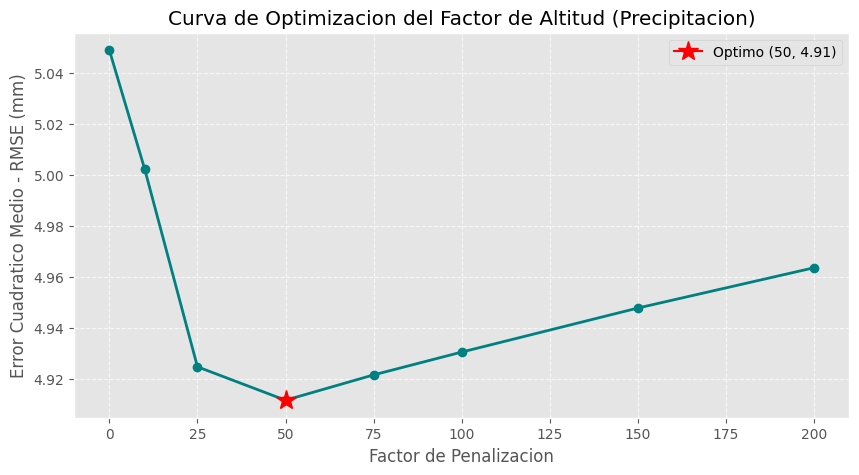

In [25]:
print("==================================================")
print("ANALISIS DE SENSIBILIDAD: OPTIMIZACION DEL FACTOR 3D")
print("==================================================")

# Factores que vamos a poner a competir
# 0 = IDW 2D plano (sin altitud). 200 = Penalización extrema.
factores_prueba = [0, 10, 25, 50, 75, 100, 150, 200]

# Función IDW exclusiva para esta prueba rápida de precipitación
def estimar_precip_prueba(fecha, estacion_obj, vecinos_info, datos_dict, factor):
    numerador, denominador = 0, 0
    for nombre_vecina, coords_vecina in vecinos_info.items():
        if nombre_vecina not in datos_dict or datos_dict[nombre_vecina].empty: continue
        try:
            val = datos_dict[nombre_vecina].loc[fecha, 'PRECIP']
            if isinstance(val, pd.Series): val = val.iloc[0]
            if pd.isna(val): continue
        except KeyError: continue

        dist_horizontal = calcular_distancia_haversine(
            estacion_obj[0], estacion_obj[1], coords_vecina[0], coords_vecina[1])
        diff_altitud = estacion_obj[2] - coords_vecina[2]

        # Aplicamos el factor de prueba actual
        dist_vertical_pond = diff_altitud * factor
        distancia_final = math.sqrt(dist_horizontal**2 + dist_vertical_pond**2)
        if distancia_final < 1: distancia_final = 1

        peso = 1 / (distancia_final ** 2)
        numerador += val * peso
        denominador += peso

    return np.nan if denominador == 0 else numerador / denominador

# Validaciones previas
if 'CENTRAL' in datos_dfs and 'PRECIP' in datos_dfs['CENTRAL'].columns:
    info_central = estaciones_info['CENTRAL']
    info_vecinos = {k: v for k, v in estaciones_info.items() if k != 'CENTRAL'}
    fechas_validas = datos_dfs['CENTRAL'].index.drop_duplicates()

    resultados_rmse = {}

    print("Calculando el error (RMSE) para cada factor. Esto tomara unos segundos...")

    for factor in factores_prueba:
        observados = []
        estimados = []

        for fecha in fechas_validas:
            obs = datos_dfs['CENTRAL'].loc[fecha, 'PRECIP']
            if isinstance(obs, pd.Series): obs = obs.iloc[0]

            # Solo evaluamos dias donde Juchitepec sí tiene un dato real para comparar
            if pd.isna(obs): continue

            est = estimar_precip_prueba(fecha, info_central, info_vecinos, datos_dfs, factor)

            if not pd.isna(est):
                observados.append(obs)
                estimados.append(est)

        # Calculo del RMSE para este factor
        if len(observados) > 0:
            rmse_actual = np.sqrt(np.mean((np.array(observados) - np.array(estimados))**2))
            resultados_rmse[factor] = rmse_actual
            print(f" -> Factor {factor:3d} | RMSE = {rmse_actual:.4f} mm")

    # Encontrar el factor ganador (el de menor error)
    factor_optimo = min(resultados_rmse, key=resultados_rmse.get)
    rmse_minimo = resultados_rmse[factor_optimo]

    print("--------------------------------------------------")
    print(f"RESULTADO: El factor optimo para Juchitepec es {factor_optimo}")
    print(f"Con este factor se logra el error mas bajo: {rmse_minimo:.4f} mm")
    print("--------------------------------------------------")

    # Graficar la curva de optimizacion

    plt.figure(figsize=(10, 5))
    x_vals = list(resultados_rmse.keys())
    y_vals = list(resultados_rmse.values())

    plt.plot(x_vals, y_vals, marker='o', linestyle='-', color='teal', linewidth=2)
    plt.plot(factor_optimo, rmse_minimo, marker='*', markersize=15, color='red',
             label=f'Optimo ({factor_optimo}, {rmse_minimo:.2f})')

    plt.title('Curva de Optimizacion del Factor de Altitud (Precipitacion)')
    plt.xlabel('Factor de Penalizacion')
    plt.ylabel('Error Cuadratico Medio - RMSE (mm)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

else:
    print("Error: Faltan datos de PRECIP en la estacion CENTRAL para hacer la prueba.")

# 6. Estimación de los datos

En esta celda se llama a la función estimar_valor para cada día de los 10 años y se forma una lista de los valores estimados y otra con los valores observados.

In [26]:
if 'CENTRAL' not in datos_dfs or datos_dfs['CENTRAL'].empty:
    print("Error: No se encontraron los datos de la estacion CENTRAL. Revisa las rutas.")
else:
    info_central = estaciones_info['CENTRAL']
    info_vecinos = {k: v for k, v in estaciones_info.items() if k != 'CENTRAL'}

    # Lista de variables
    variables = ['TMAX', 'TMIN', 'PRECIP']

    fechas_proceso = datos_dfs['CENTRAL'].index.drop_duplicates()
    resultados = pd.DataFrame(index=fechas_proceso)

    print("Iniciando la estimacion de las series temporales...")

    for var in variables:
        if var not in datos_dfs['CENTRAL'].columns:
            print(f" -> Saltando {var}: Columna no encontrada en Juchitepec.")
            continue

        print(f" -> Procesando {var} usando datos de las estaciones vecinas...")
        lista_estimados = []
        lista_observados = []

        for fecha in fechas_proceso:
            obs = datos_dfs['CENTRAL'].loc[fecha, var]
            if isinstance(obs, pd.Series): obs = obs.iloc[0]

            lista_observados.append(obs)
            lista_estimados.append(estimar_valor(fecha, var, info_central, info_vecinos, datos_dfs))

        resultados[f'{var}_OBS'] = lista_observados
        resultados[f'{var}_EST'] = lista_estimados

    print("\nPaso 6 completado.")
    print("Vista previa de los calculos finalizados:")
    display(resultados.dropna(how='all').head(10))

Iniciando la estimacion de las series temporales...
 -> Procesando TMAX usando datos de las estaciones vecinas...
 -> Procesando TMIN usando datos de las estaciones vecinas...
 -> Procesando PRECIP usando datos de las estaciones vecinas...

Paso 6 completado.
Vista previa de los calculos finalizados:


,TMAX_OBS,TMAX_EST,TMIN_OBS,TMIN_EST,PRECIP_OBS,PRECIP_EST
FECHA,,,,,,
2015-01-01,19.0,20.144704,6.0,4.988725,3.4,0.000000
2015-01-02,20.0,19.559578,6.0,4.679124,0.0,0.000000
2015-01-03,21.0,18.825863,8.0,5.081829,1.5,0.000000
2015-01-04,21.0,19.869311,6.0,4.617422,2.3,0.000000
2015-01-05,20.0,17.201310,7.0,3.720947,0.0,0.000000
2015-01-06,19.0,18.224367,6.0,2.691985,0.0,0.000000
2015-01-07,19.0,19.952743,6.0,3.945841,1.2,0.000000
2015-01-08,20.0,17.061924,7.0,4.025537,0.0,0.000000
2015-01-09,21.0,18.994537,6.0,3.027230,0.0,0.001251


# 7. Análisis y gráficas

--------------------------------------------------
RESULTADOS DE HOMOGENEIDAD PARA: TMAX (JUCHITEPEC)
Correlacion de Pearson: 0.6099
Raiz del Error Cuadratico Medio (RMSE): 2.8549
--------------------------------------------------


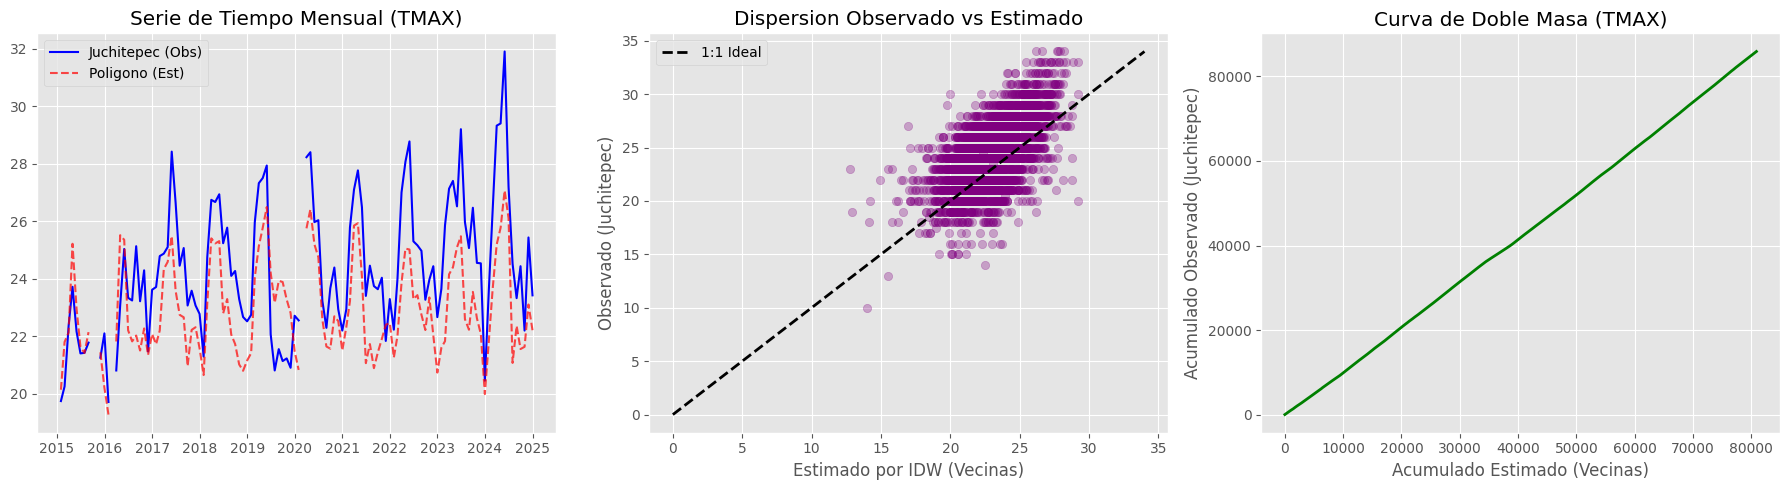

In [27]:
# Variables disponibles: 'TMAX', 'TMIN', 'PRECIP'
var_analisis = 'TMAX'

if 'resultados' in locals() and f'{var_analisis}_OBS' in resultados.columns:
    # Filtramos nulos para que las metricas funcionen
    datos_validos = resultados[[f'{var_analisis}_OBS', f'{var_analisis}_EST']].dropna()

    if len(datos_validos) > 0:
        corr = datos_validos[f'{var_analisis}_OBS'].corr(datos_validos[f'{var_analisis}_EST'])
        rmse = np.sqrt(((datos_validos[f'{var_analisis}_OBS'] - datos_validos[f'{var_analisis}_EST']) ** 2).mean())

        print("--------------------------------------------------")
        print(f"RESULTADOS DE HOMOGENEIDAD PARA: {var_analisis} (JUCHITEPEC)")
        print(f"Correlacion de Pearson: {corr:.4f}")
        print(f"Raiz del Error Cuadratico Medio (RMSE): {rmse:.4f}")
        print("--------------------------------------------------")

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1. Serie de Tiempo Mensualizada
        if var_analisis == 'PRECIP':
            res_mensual = datos_validos.resample('ME').sum()
        else:
            res_mensual = datos_validos.resample('ME').mean()

        axes[0].plot(res_mensual.index, res_mensual[f'{var_analisis}_OBS'], label='Juchitepec (Obs)', color='blue')
        axes[0].plot(res_mensual.index, res_mensual[f'{var_analisis}_EST'], label='Poligono (Est)', color='red', linestyle='--', alpha=0.7)
        axes[0].set_title(f'Serie de Tiempo Mensual ({var_analisis})')
        axes[0].legend()

        # 2. Diagrama de Dispersion
        axes[1].scatter(datos_validos[f'{var_analisis}_EST'], datos_validos[f'{var_analisis}_OBS'], alpha=0.3, color='purple')
        min_val = min(datos_validos.min().min(), 0)
        max_val = datos_validos.max().max()
        axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='1:1 Ideal')
        axes[1].set_title(f'Dispersion Observado vs Estimado')
        axes[1].set_xlabel('Estimado por IDW (Vecinas)')
        axes[1].set_ylabel('Observado (Juchitepec)')
        axes[1].legend()

        # 3. Curva de Doble Masa
        acum_obs = datos_validos[f'{var_analisis}_OBS'].cumsum()
        acum_est = datos_validos[f'{var_analisis}_EST'].cumsum()
        axes[2].plot(acum_est, acum_obs, color='green', linewidth=2)
        axes[2].set_title(f'Curva de Doble Masa ({var_analisis})')
        axes[2].set_xlabel('Acumulado Estimado (Vecinas)')
        axes[2].set_ylabel('Acumulado Observado (Juchitepec)')

        plt.tight_layout()
        plt.show()
    else:
        print(f"No hay suficientes registros validos para analizar {var_analisis}.")
else:
    print(f"La variable 'resultados' no esta lista o no contiene la columna {var_analisis}_OBS.")

EVALUACION DEL MODELO: RMSE vs DESVIACION ESTANDAR
Estacion: JUCHITEPEC (CENTRAL) - Variable: PRECIP
 -> Media diaria historica: 1.6837 mm
 -> Desviacion Estandar (σ):  4.3971 mm
 -> RMSE del modelo IDW:    4.9116 mm
--------------------------------------------------
El RMSE es MAYOR o IGUAL a la desviacion estandar.
Esto advierte que la interpolacion tiene mucho ruido, probablemente debido a la alta variabilidad espacial orografica de la lluvia en esta zona.


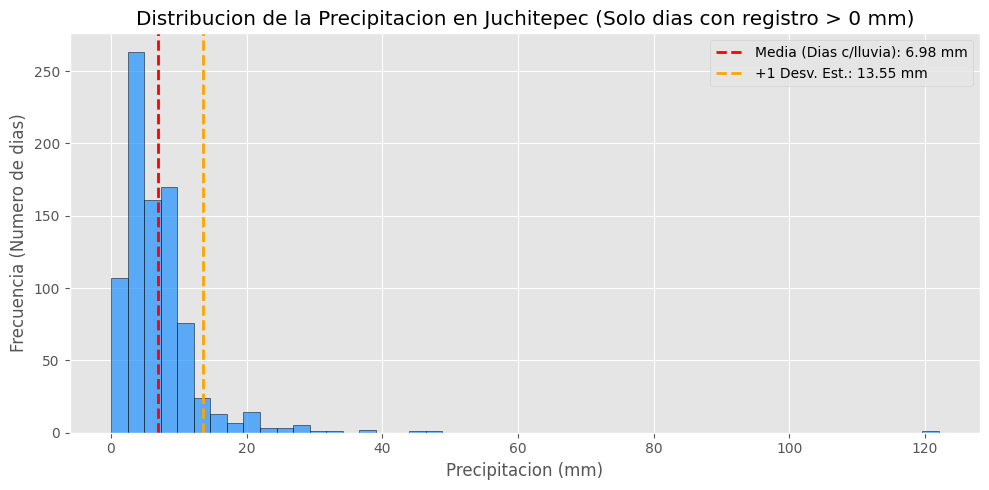

In [30]:
print("==================================================")
print("EVALUACION DEL MODELO: RMSE vs DESVIACION ESTANDAR")
print("==================================================")

# Definimos la variable a evaluar
var_eval = 'PRECIP'

# Verificar que tenemos los datos crudos de Juchitepec
if 'CENTRAL' in datos_dfs and var_eval in datos_dfs['CENTRAL'].columns:
    # 1. Extraer los datos reales limpios (sin nulos)
    obs_reales = datos_dfs['CENTRAL'][var_eval].dropna()

    # 2. Calcular Media y Desviacion Estandar de lo observado
    media_obs = obs_reales.mean()
    desv_est_obs = obs_reales.std()

    print(f"Estacion: JUCHITEPEC (CENTRAL) - Variable: {var_eval}")
    print(f" -> Media diaria historica: {media_obs:.4f} mm")
    print(f" -> Desviacion Estandar (\u03c3):  {desv_est_obs:.4f} mm")

    # 3. Traer el RMSE calculado en las estimaciones (si existe la variable 'resultados')
    if 'resultados' in locals() and f'{var_eval}_EST' in resultados.columns:
        datos_validos = resultados[[f'{var_eval}_OBS', f'{var_eval}_EST']].dropna()
        rmse_calc = np.sqrt(((datos_validos[f'{var_eval}_OBS'] - datos_validos[f'{var_eval}_EST']) ** 2).mean())

        print(f" -> RMSE del modelo IDW:    {rmse_calc:.4f} mm")
        print("--------------------------------------------------")

        # 4. Diagnostico automatico
        if rmse_calc < desv_est_obs:
            print("El RMSE es MENOR que la desviacion estandar.")
            print("Esto indica que el poligono de estaciones vecinas aporta informacion valiosa y estima la lluvia mejor que el simple promedio.")
        else:
            print("El RMSE es MAYOR o IGUAL a la desviacion estandar.")
            print("Esto advierte que la interpolacion tiene mucho ruido, probablemente debido a la alta variabilidad espacial orografica de la lluvia en esta zona.")
    else:
        print("Nota: Asegurate de haber ejecutado la Celda 6 para calcular el RMSE y hacer la comparacion.")

    # 5. Grafica de Distribucion (Histograma)
    # Filtramos solo los dias donde llovio (>0) para que la grafica no este dominada por los dias secos
    dias_con_lluvia = obs_reales[obs_reales > 0]

    plt.figure(figsize=(10, 5))
    plt.hist(dias_con_lluvia, bins=50, color='dodgerblue', edgecolor='black', alpha=0.7)

    # Lineas de referencia
    plt.axvline(dias_con_lluvia.mean(), color='red', linestyle='dashed', linewidth=2,
                label=f'Media (Dias c/lluvia): {dias_con_lluvia.mean():.2f} mm')
    plt.axvline(dias_con_lluvia.mean() + dias_con_lluvia.std(), color='orange', linestyle='dashed', linewidth=2,
                label=f'+1 Desv. Est.: {(dias_con_lluvia.mean() + dias_con_lluvia.std()):.2f} mm')

    plt.title(f'Distribucion de la Precipitacion en Juchitepec (Solo dias con registro > 0 mm)')
    plt.xlabel('Precipitacion (mm)')
    plt.ylabel('Frecuencia (Numero de dias)')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Error: No se encontraron los datos de Juchitepec para hacer el calculo.")

# 8. Descarga de los datos

In [29]:
if 'resultados' in locals() and not resultados.empty:
    archivo_salida = 'Juchitepec_Homogeneidad_TMAX_TMIN_PRECIP_2015_2024.csv'
    resultados.to_csv(archivo_salida, index=True)

    print("Columnas exportadas: ", list(resultados.columns))
else:
    print("No hay datos calculados para exportar.")

Columnas exportadas:  ['TMAX_OBS', 'TMAX_EST', 'TMIN_OBS', 'TMIN_EST', 'PRECIP_OBS', 'PRECIP_EST']
